# Eksperimen Machine Learning System Management Lifecycle (MSML)

Nama: Muhammad Alif Aditya  
Dataset: Red Wine Quality (Cortez et al., 2009)  
Tujuan: Melakukan eksplorasi, EDA, dan preprocessing data sebagai dasar otomatisasi preprocessing.


# **1. Perkenalan Dataset**


**Sumber Dataset**:  
   Dataset yang digunakan adalah Red Wine Quality dari UCI Machine Learning Repository. Dataset ini berisi parameter kimiawi dari varian "Red Wine" dari anggur Vinho Verde Portugal. Target utamanya adalah memprediksi kualitas wine (skor 0-10) berdasarkan tes fisikokimia. Untuk eksperimen ini, kita akan mengubahnya menjadi klasifikasi biner: Good Wine (Quality >= 7) dan Bad Wine (Quality < 7).

# **2. Import Library**

Pada tahap ini, Anda perlu mengimpor beberapa pustaka (library) Python yang dibutuhkan untuk analisis data dan pembangunan model machine learning atau deep learning.

In [5]:
import pandas as pd
import numpy as np
import os
import shutil
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Setting visualisasi
sns.set(style="whitegrid")

# **3. Memuat Dataset**

Pada tahap ini, Anda perlu memuat dataset ke dalam notebook. Jika dataset dalam format CSV, Anda bisa menggunakan pustaka pandas untuk membacanya. Pastikan untuk mengecek beberapa baris awal dataset untuk memahami strukturnya dan memastikan data telah dimuat dengan benar.

Jika dataset berada di Google Drive, pastikan Anda menghubungkan Google Drive ke Colab terlebih dahulu. Setelah dataset berhasil dimuat, langkah berikutnya adalah memeriksa kesesuaian data dan siap untuk dianalisis lebih lanjut.

Jika dataset berupa unstructured data, silakan sesuaikan dengan format seperti kelas Machine Learning Pengembangan atau Machine Learning Terapan

In [3]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("uciml/red-wine-quality-cortez-et-al-2009")

print("Path to dataset files:", path)

/Users/macm4/repositories/MLOps-RedWine-Dashboard/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


100%|██████████| 25.6k/25.6k [00:00<00:00, 1.54MB/s]

Extracting files...
Path to dataset files: /Users/macm4/.cache/kagglehub/datasets/uciml/red-wine-quality-cortez-et-al-2009/versions/2


In [6]:
# Destination folder (change to the folder you want)
dest_dir = os.path.join(os.getcwd(), "..")
os.makedirs(dest_dir, exist_ok=True)
    
# Move / unpack depending on returned path type
if os.path.isdir(path):
    for name in os.listdir(path):
        shutil.move(os.path.join(path, name), dest_dir)
    try:
        os.rmdir(path)
    except OSError:
        pass
elif os.path.isfile(path):
    lower = path.lower()
    if lower.endswith((".zip", ".tar", ".tar.gz", ".tgz")):
        shutil.unpack_archive(path, dest_dir)
        os.remove(path)
    else:
        shutil.move(path, os.path.join(dest_dir, os.path.basename(path)))

print("Files moved/unpacked to:", dest_dir)

Files moved/unpacked to: /Users/macm4/repositories/MLOps-RedWine-Dashboard/Eksperimen_SML_Muhammad-Alif-Aditya/preprocessing/..


In [16]:
#Type your code h# Pastikan file winequality_raw.csv ada di direktori yang sama
df = pd.read_csv('../winequality-red.csv')

# Menampilkan 5 baris pertama
print("5 Data Teratas:")
display(df.head())

5 Data Teratas:


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5


# **4. Exploratory Data Analysis (EDA)**

Pada tahap ini, Anda akan melakukan **Exploratory Data Analysis (EDA)** untuk memahami karakteristik dataset.

Tujuan dari EDA adalah untuk memperoleh wawasan awal yang mendalam mengenai data dan menentukan langkah selanjutnya dalam analisis atau pemodelan.

In [17]:
# Memeriksa struktur data
print("\nInformasi Dataset:")
df.info()


Informasi Dataset:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1599 entries, 0 to 1598
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         1599 non-null   float64
 1   volatile acidity      1599 non-null   float64
 2   citric acid           1599 non-null   float64
 3   residual sugar        1599 non-null   float64
 4   chlorides             1599 non-null   float64
 5   free sulfur dioxide   1599 non-null   float64
 6   total sulfur dioxide  1599 non-null   float64
 7   density               1599 non-null   float64
 8   pH                    1599 non-null   float64
 9   sulphates             1599 non-null   float64
 10  alcohol               1599 non-null   float64
 11  quality               1599 non-null   int64  
dtypes: float64(11), int64(1)
memory usage: 150.0 KB


In [12]:
df.describe()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
count,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000
mean,8.319637,0.527821,0.270976,2.538806,0.087467,15.874922,46.467792,0.996747,3.311113,0.658149,10.422983,5.636023
std,1.741096,0.179060,0.194801,1.409928,0.047065,10.460157,32.895324,0.001887,0.154386,0.169507,1.065668,0.807569
min,4.600000,0.120000,0.000000,0.900000,0.012000,1.000000,6.000000,0.990070,2.740000,0.330000,8.400000,3.000000
25%,7.100000,0.390000,0.090000,1.900000,0.070000,7.000000,22.000000,0.995600,3.210000,0.550000,9.500000,5.000000
50%,7.900000,0.520000,0.260000,2.200000,0.079000,14.000000,38.000000,0.996750,3.310000,0.620000,10.200000,6.000000
75%,9.200000,0.640000,0.420000,2.600000,0.090000,21.000000,62.000000,0.997835,3.400000,0.730000,11.100000,6.000000
max,15.900000,1.580000,1.000000,15.500000,0.611000,72.000000,289.000000,1.003690,4.010000,2.000000,14.900000,8.000000


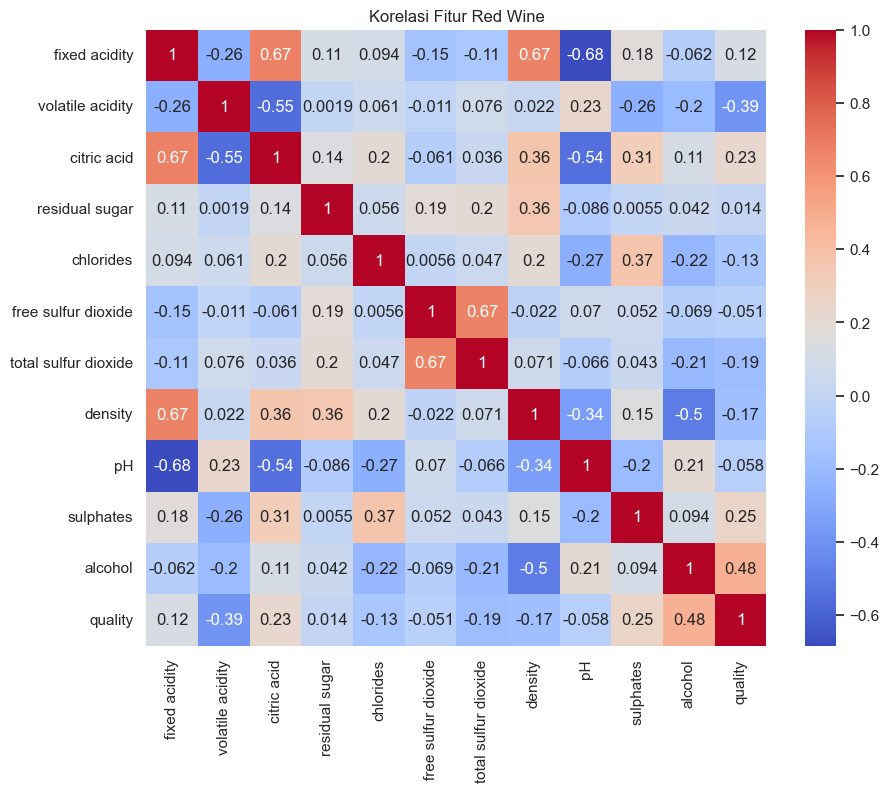

In [13]:
# Visualisasi korelasi
plt.figure(figsize=(10, 8))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm')
plt.title("Korelasi Fitur Red Wine")
plt.show()

# **5. Data Preprocessing**

Pada tahap ini, data preprocessing adalah langkah penting untuk memastikan kualitas data sebelum digunakan dalam model machine learning.

Jika Anda menggunakan data teks, data mentah sering kali mengandung nilai kosong, duplikasi, atau rentang nilai yang tidak konsisten, yang dapat memengaruhi kinerja model. Oleh karena itu, proses ini bertujuan untuk membersihkan dan mempersiapkan data agar analisis berjalan optimal.

Berikut adalah tahapan-tahapan yang bisa dilakukan, tetapi **tidak terbatas** pada:
1. Menghapus atau Menangani Data Kosong (Missing Values)
2. Menghapus Data Duplikat
3. Normalisasi atau Standarisasi Fitur
4. Deteksi dan Penanganan Outlier
5. Encoding Data Kategorikal
6. Binning (Pengelompokan Data)

Cukup sesuaikan dengan karakteristik data yang kamu gunakan yah. Khususnya ketika kami menggunakan data tidak terstruktur.

In [15]:
# 1. Menghapus Duplikat
df = df.drop_duplicates()

# 2. Binning/Labelling (Quality >= 7 dikategorikan '1', sisanya '0')
df['target'] = (df['quality'] >= 7).astype(int)
df = df.drop('quality', axis=1)

# 3. Standarisasi Fitur
scaler = StandardScaler()
features = df.drop('target', axis=1)
df_scaled = pd.DataFrame(scaler.fit_transform(features), columns=features.columns)
df_scaled['target'] = df['target'].values

# Simpan hasil
df_scaled.to_csv('winequality_preprocessed.csv', index=False)